# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [3]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categóricas?**



Las variables que son numericas son la edad, fare, Parch y el SibSp. Las variables que son categóricas son survived, el tipo de clase, el sexo, la cabina y el lugar de embarque.

# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

**RESPUESTAS:**
- Hay 891 pasajeros. 
- Contiene información de cada persona sobre el sexo, la edad, la tarifa que pagaron, donde abordaron, entre otras cosas. 
- A primera vista hay una mayor cantidad de Hombres que Mujeres, y por su parte las clases, las cuales son 3 no parecen  tener una tendencia en especial, en otra palabras ambas son distribuciones discretas. 
- Aparece un gran rango de edades, desde que son bebes (~2 años), hasta ancianos (~70 años), osea una distribución continua.
- La tarifa también es una distribución continua, va desde los pocos dólares hasta el orden de los cientos. 
- Hay de todo, gente que viajo sola y otra que viajo con familiares, ya sea uno o más de un familiar.
- El puerto de embarque vendría a ser una variable categórica, las posibilidades son Qeenstown, Southampton y Cherbourg.

In [4]:
with open("titanic_semana_02.csv", "r", encoding="utf-8") as archivo:
    total_filas = sum(1 for linea in archivo)

print(f'La cantidad de pasajeros abordo del Titanic es: {total_filas - 1}')


La cantidad de pasajeros abordo del Titanic es: 891


### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


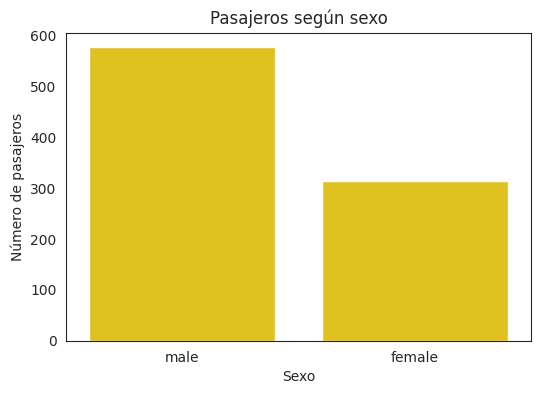

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


**RESPUESTAS:**
- La clase 3 es la que posee mayor cantidad de pasajeros. 
- No esta balanceada, la clase 3 es mayor en cantidad aún sumando los pasajeros de la clase 1 y 2.

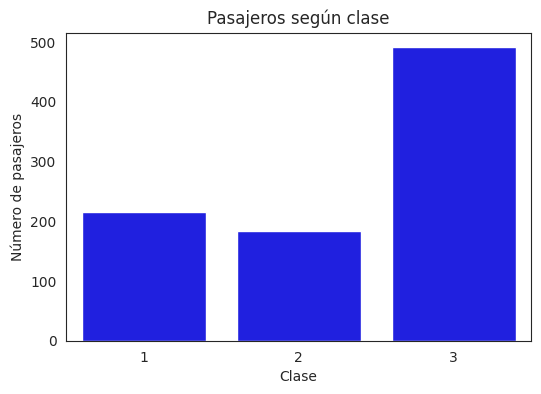

In [6]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="blue")

plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")

plt.show()


**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


**RESPUESTAS:**
- El rango que vas desde los 20 a 30 años son las más frecuentes. 
- Es más o menos simétrica, se asemeja a una gaussiana, centrada entre 20 y 30 años de edad.
- La verdad no cambia mucho la interpretación, mantiene su forma, pero si deja algunas edades sin ningún valor.

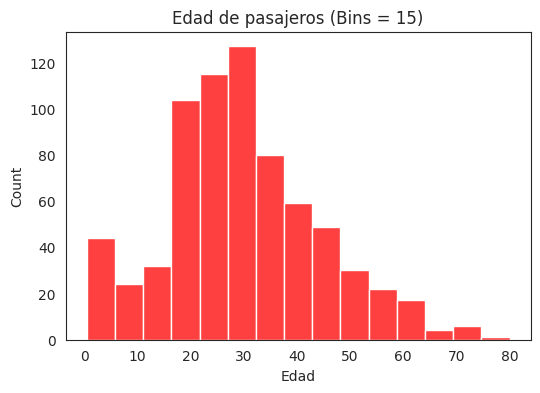

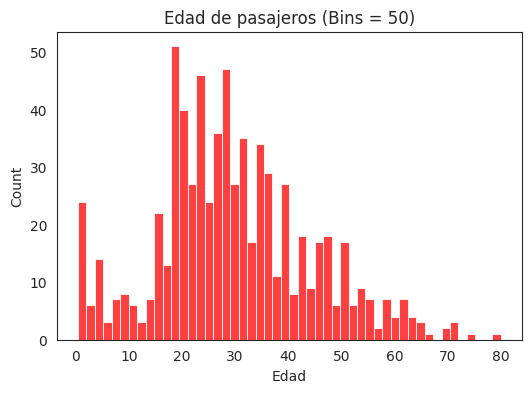

In [25]:
# Escriba aquí su código
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x='Age', bins=15, color='red')

plt.xlabel("Edad")
plt.title("Edad de pasajeros (Bins = 15)")

plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x='Age', bins=50, color='red')

plt.xlabel("Edad")
plt.title("Edad de pasajeros (Bins = 50)")

plt.show()

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


**RESPUESTAS:**
- No, no es para nada simétrica, hay poca cantidad de personas que pagaron más de 100 por su boleto, la gráfica tiene una acumulación de gente en los valores más bajos.
- Si existen, algunas pasan los 100 e inclusive hay una tarifa que pasa los 500. 
- Que había poca gente muy privilegiada, lo que iría de la mano con la cantidad de gente por clase.

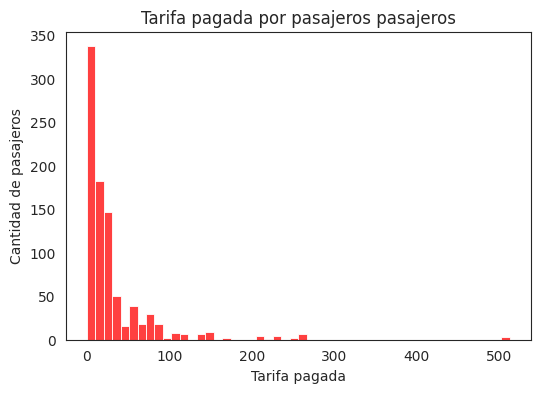

In [26]:
# Escriba aquí su código
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x='Fare', bins=50, color='red')

plt.xlabel("Tarifa pagada")
plt.ylabel("Cantidad de pasajeros")
plt.title("Tarifa pagada por pasajeros pasajeros")
plt.show()


# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


**RESPUESTA:**
A muchos pasajeros les falta el dato de la edad y la cabina. Esto importa porque nos daria una idea de las características de los pasajeros que si sobrevivieron y a su vez de los que no lo hicieron. 

In [9]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


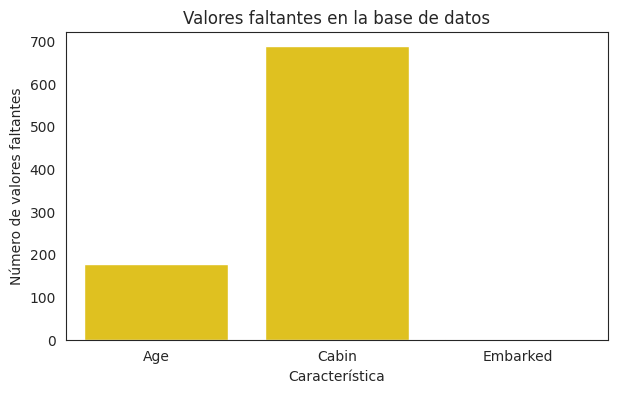

In [10]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


**RESPUESTA:** 
- Si son similares, la media es de 29.7 años y la mediana es de 28.0 años, practicamente solo difieren por dos años.
- A mi parecer no, la mejor representación de la edad típica es la mediana, ya que es más robusta y no se influencia tanto por los outliers como si ocurre con la media.

/tmp/ipykernel_44449/4208339636.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic, x='Embarked', palette='inferno', ax=d3)


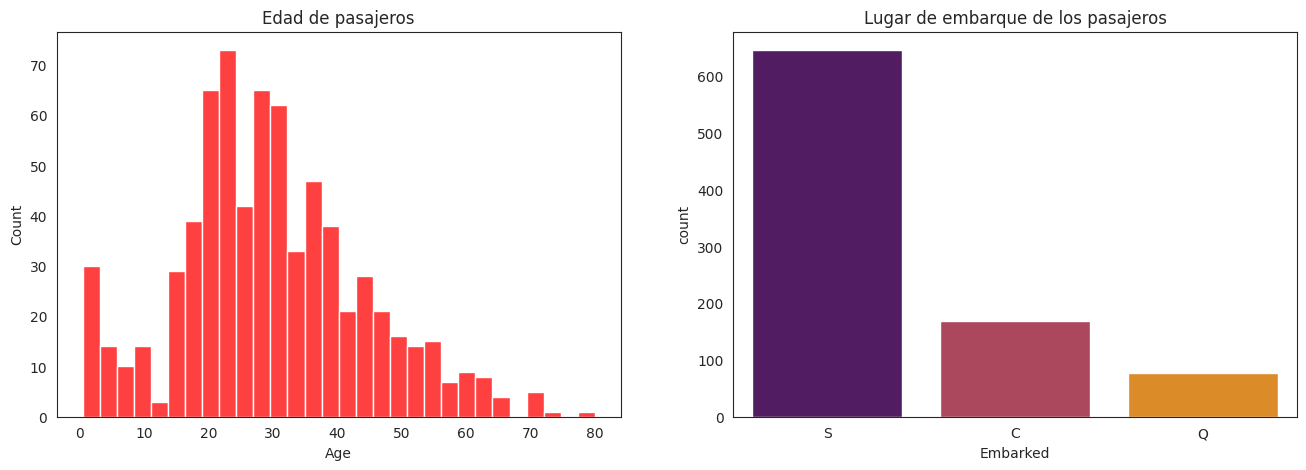

In [34]:
fig, (d1, d3) = plt.subplots(1, 2, figsize=(16, 5))

# Le pasamos el parámetro ax a cada gráfico para decirle exactamente dónde ubicarse
sns.histplot(data=titanic, x='Age', color='red', bins=30, ax=d1)
sns.countplot(data=titanic, x='Embarked', palette='inferno', ax=d3)

# Ponemos los títulos apuntando directamente a los espacios (d1, d2, d3)
d1.set_title("Edad de pasajeros")
d3.set_title("Lugar de embarque de los pasajeros")

plt.show()

In [11]:
# Escriba aquí su código
Age_clean = []

for i in titanic['Age']:

    if pd.notna(i):

        Age_clean.append(i)            

media = np.mean(Age_clean)
mediana = np.median(Age_clean)

print(f'La media de Age es: {media:.2f}')
print(f'La mediana de Age es: {mediana:.2f}')

La media de Age es: 29.70
La mediana de Age es: 28.00


**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?


**RESPUESTAS:**
- Si por alguna razón se necesitara tener si o si esos datos, me parece razonable, ya que representa bien la muestra, pero sino es necesario no lo haría, ya que se estarian considerando datos que no son reales, lo que trae problemas. 
- Produciria cierto sesgo, ya que ese valor de edad crecería muchisimo (casi 200 personas más), el valor se dispara, arruinando la muestra con valores que en realidad no existen, no se tiene registro de ellos.
- Se podrían reemplazar los valores que faltan por los valores más repetidos (por ejemplo, por las 10 edades que mas se repiten), de este modo la muestra seguiria la misma tendencia que sin estos valores. Pero a mi parecer se sigue generando el mismo sesgo que antes, solo que en menor magnitud, por lo cual lo más correcto para mi sigue siendo no reemplazar estos valores, simplemente no considerarlos.

**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.


**RESPUESTAS:**
- No los reemplazaria, ya que como se menciono antes genera un sesgo que termina arruinando la muestra de cierta forma.
- Creo que seria una buena opción eliminar la característica, ya que no aporta demasiada información esta variable, o por lo menos no afecta directa o indirectamente a las otras variables. 
- La verdad por si sola no, solo dice la cabina, no sabemos en que lugar esta esa cabina, o si es más costosa, o si es exclusiva de algún sexo. No entrega mayor información que solo la cabina, la cual es distinta para todos los pasajeros.

**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?


**RESPUESTA:**
- Lo distribuiria equitativamente en los tres posibles embarques, de este modo la estadistica y/o tendencia no se ve afectada.
- Por un lado al ser tan pocos datos faltantes la gráfica no sufre grandes cambios. Pero lo más importante sería que en general hay muchisimas cabinas, por lo que no se puede establecer nada con eso, hay muchas posibilidades, no hay algo que marque una moda. En cambio solo hay tres posibles embarques, por lo que se puede extraer información y establecer estadisticas más facilmente, inclusive predecir algún proximo embarque.

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


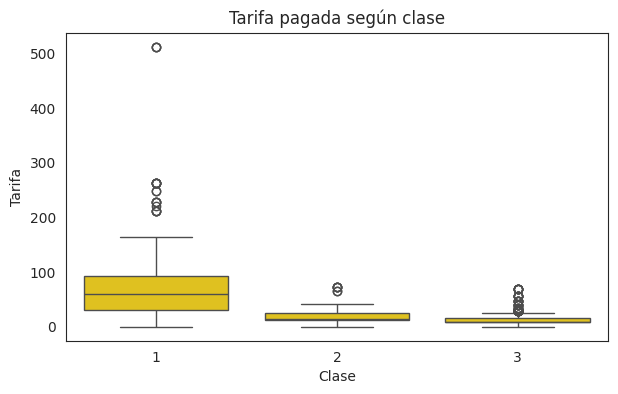

In [12]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?


**RESPUESTAS:**
- Si, se ve que son directamente proporcionales, las tarifas más altas corresponden a los de Clase 1.
- Si hay dispersión, pero es mayor para los de clase 1, ya que hay gente con tarifas muy altas (mas de 100).
- Si, justo como mencioné hay gente que pago casi 10 veces lo que pago el promedio de pasajeros. 
. No necesariamente, ya que las tarifas entre los pasajeros de Clase 2 y 3 son bastante semejantes en cuanto a lo que la gráfica muestra, la Clase 1 se podría más o menos decir que contienen la misma información, aunque no seria del todo cierto, ya que también hay gente con tarifas bajas. 

### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?


**RESPUESTAS:** 
- Más o menos si, a simple vista si, pero al mirar con mayor detención se ve como la Clase 1 posee gente de edad más avanzada y la Clase 3 posee una concentración de pasajeros más jovenes. 
- Como ya mencione, la clase 1 posee pasajeros de edades más avanzadas que las otras, a su vez la clase 3 presenta pasajeros más jóvenes en su mayoria. 

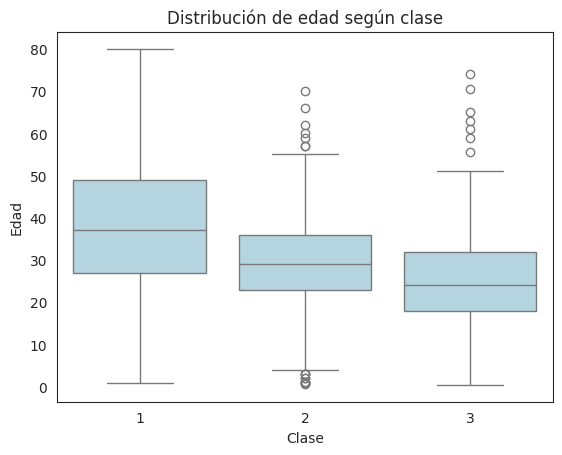

In [13]:
# Escriba aquí su código
sns.boxplot(data=titanic, x = 'Pclass', y = 'Age', color = 'lightblue')

plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Distribución de edad según clase")

plt.show()


**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [14]:
# Complete el código

titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1

titanic[['SibSp', 'Parch', 'Familia']].head(10)

,SibSp,Parch,Familia
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?


**RESPUESTAS:**
- La mayoría de pasajeros viajaba sin acompañantes. 
- Si hay grupos familiares bastante grandes, de 8 o más personas, pero estos casos son escasos. 
- Si, ya que hay pasajeros que viajaron solo viajó con sus padres o hijos, otros que solo viajaron con hermanos o conyuges y hay otros que viajaron con ambos tipos de personas. Por lo cual, si se analizan por separado se perdería el tamaño real de la Familia. 

Distribución de pasajeros por tamaño de familia:
Familia
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64
Pasajeros viajando solos: 537
Pasajeros viajando acompañados: 354


/tmp/ipykernel_44449/1314884517.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic, x='Familia', palette='viridis')


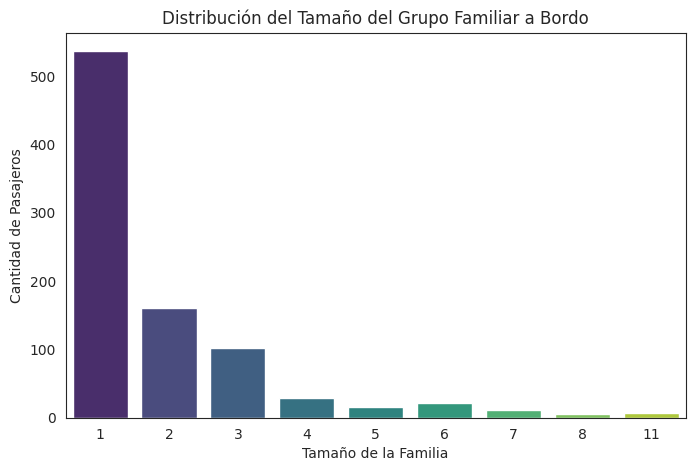

In [15]:
# Escriba aquí su código
print("Distribución de pasajeros por tamaño de familia:")
# value_counts() cuenta, y sort_index() ordena la salida del 1 en adelante
print(titanic['Familia'].value_counts().sort_index())

# Para ver rápidamente si viajaban más solos o acompañados:
solos = (titanic['Familia'] == 1).sum()
acompañados = (titanic['Familia'] > 1).sum()

print(f"Pasajeros viajando solos: {solos}")
print(f"Pasajeros viajando acompañados: {acompañados}")

# --- Visualización con Countplot ---
plt.figure(figsize=(8, 5))
sns.countplot(data=titanic, x='Familia', palette='viridis')
plt.title('Distribución del Tamaño del Grupo Familiar a Bordo')
plt.xlabel('Tamaño de la Familia')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


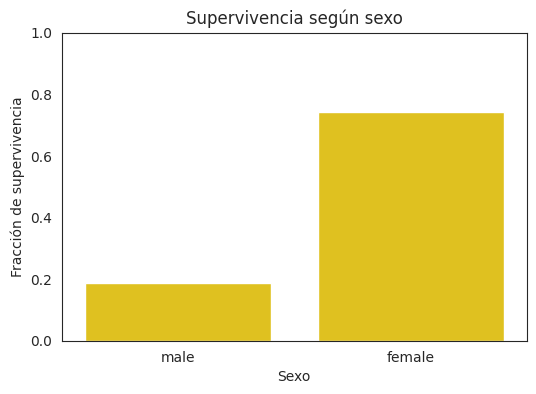

In [16]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?


**RESPUESTAS:**
- Para nada son iguales, las mujeres tienen más de un 0.7 de fracción de supervivencia, mientras que los hombres cerca de 0.2. Las mujeres sobrevivieron 3 veces más que los hombres porcentualmente.
- No, no se puede inferir a partir de este gráfico, solo se podría pensar en los posibles escenarios que llevaron a que esto pasara, pero solo con la información del gráfico no se puede determinar la diferencia. 

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?


**RESPUESTAS:**
- Si, hay diferencias notorias, donde la mayor fracción de supervivencia la tienen los pasajeros de la Clase 1.
- La tendencia se podría pensar como que la mejor clase (1), fue en la que mayor fracción de supervivencia posee.

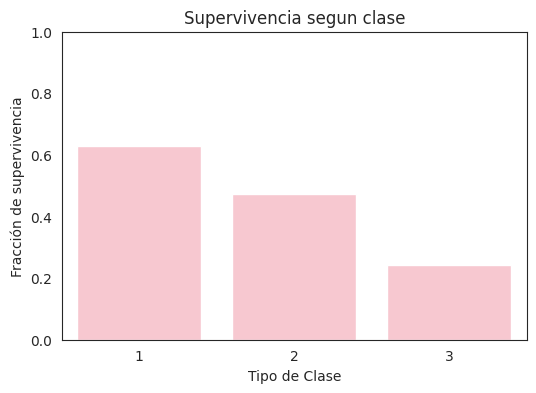

In [17]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='pink')

plt.xlabel("Tipo de Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia segun clase")
plt.ylim(0,1)

plt.show()


**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?


**RESPUESTAS:**
- Si, pero bastante poco, se ve como las edades más bajas (<16 años) tuvieron mayor fracción de supervivencia en comparación al resto.
- Me llama la atención los grupos que más pasajeros poseían, ya que su fracción de supervivencia es muy baja, menos de la mitad de las personas en ese rango sobrevivieron. 

/tmp/ipykernel_44449/4176618996.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Supervivencia (0 = No, 1 = Sí)')


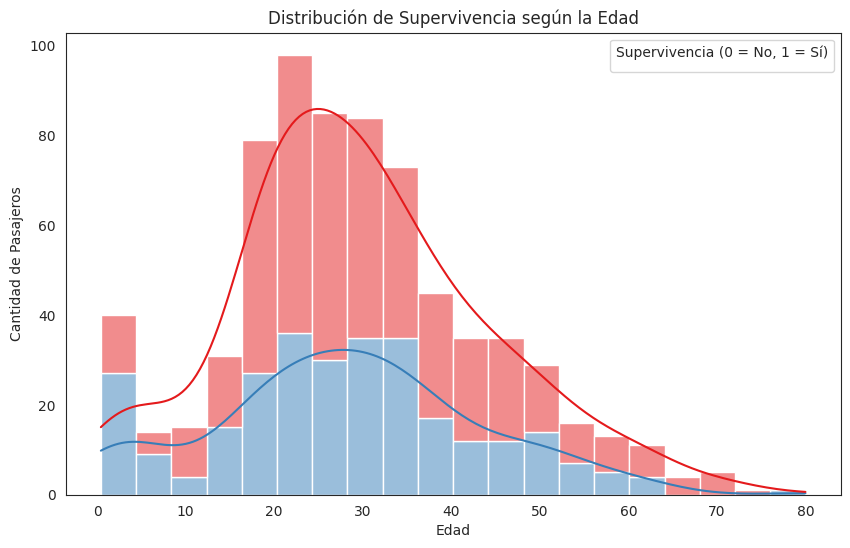

In [18]:
# Escriba aquí su código
plt.figure(figsize=(10, 6))
sns.histplot(data=titanic, x='Age', hue='Survived', multiple='stack', kde=True, palette='Set1')

plt.title('Distribución de Supervivencia según la Edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Supervivencia (0 = No, 1 = Sí)')
plt.show()


**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?


**RESPUESTAS:**
- Viajar solo parece desfavorable, tiene una fracción de supervivencia de casi 0.3, una de las más bajas.
- No parece para nada simple, no hay tendencia clara, solo se ve que la mayor fracción de supervivencia la tiene la familia con 4 integrantes. A su vez las más numerosas no sobrevivieron. Por lo cual no parece que haya una relación entre el tamaño de la familia y la supervivencia. 
- Como ya mencione, los grupos familiares grandes son lo que tienen menor fracción de supervivencia a excepción de las familias con 7 integrantes.

/tmp/ipykernel_44449/3651399621.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Familia', y='Survived', data=titanic, palette='magma', capsize=0.1, errorbar=None)


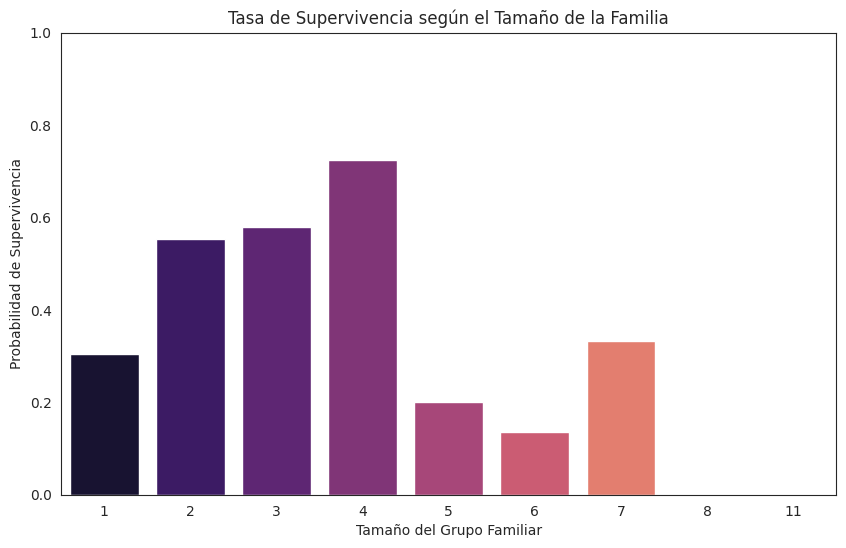

In [54]:
# Escriba aquí su código
plt.figure(figsize=(10, 6))
# barplot calcula el promedio de 'Survived' para cada tamaño de 'Familia'
sns.barplot(x='Familia', y='Survived', data=titanic, palette='magma', capsize=0.1, errorbar=None)

plt.title('Tasa de Supervivencia según el Tamaño de la Familia')
plt.xlabel('Tamaño del Grupo Familiar')
plt.ylabel('Probabilidad de Supervivencia')
plt.ylim(0.0, 1.0)
plt.show()

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


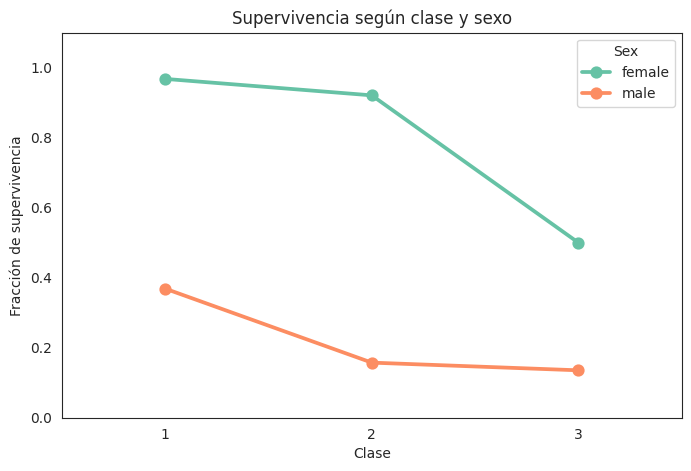

In [20]:
plt.figure(figsize=(8,5))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1.1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?



**RESPUESTAS:**
- Pareciera que tienen más o menos la misma relación, la clase 1 posee mayor fracción de supervivencia y la clase 3 posee la más baja. Aunque hay que mencionar que en el caso de los hombres la clase 2 y 3 poseen casi la misma fracción de supervivencia.
- Que las mujeres poseen por mucho una fracción de supervivencia mucho más alta. Si solo se observa la clase, se pierde esa distinción entre sexos.
- Cuando solo se observaba el sexo, se pierde la distribución de esa supervivencia, cuando se ven a la par el tipo de clase y el sexo, se ve la tendencia de que a mejor clase es mayor la fracción de sobreviviente y también como las mujeres sobreviven en mayor proporción. 
- El grupo más favorecido son las mujeres pertenecientes a la clase 1, y el grupo menos favorecido son los hombres de la clase 3.

### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [21]:
# Complete el código
condiciones = [(titanic['Age'] < 16), (titanic['Sex'] == 'female')]
opciones = ['Niño/a', 'Mujer']

titanic["Persona"] = np.select(condiciones, opciones, default='Hombre')

# Revise el resultado
titanic["Persona"].value_counts()

Persona
Hombre    537
Mujer     271
Niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


**RESPUESTAS:**
- No, no poseen el mismo patrón hombres y niños, los niños que mayor fracción de supervivencia poseen son los de clase 2, mientras que para los hombres son los que pertenecen a la clase 1.
- Para hombres y mujeres se puede decir que si, pero para los niños no. Para los primeros 2 se cumple que la clase 1 es la que tiene mayores posibilidades de sobrevivir, mientras que para los niños es la clase 2, como afirme anteriormente.
- Mujer perteneciente a la clase 1, o niño perteneciente a la clase 2, serían las combinaciones con mayor tasa de supervivencia.

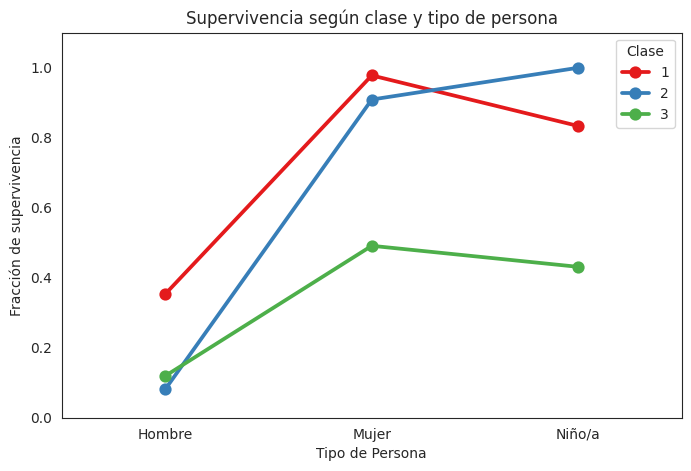

In [22]:
# Escriba aquí su código
plt.figure(figsize=(8,5))

sns.pointplot(data=titanic,
              x="Persona",
              y="Survived",
              hue="Pclass",
              palette="Set1",
              errorbar=None)

plt.xlabel("Tipo de Persona")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y tipo de persona")
plt.legend(title='Clase')
plt.ylim(0,1.1)

plt.show()

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


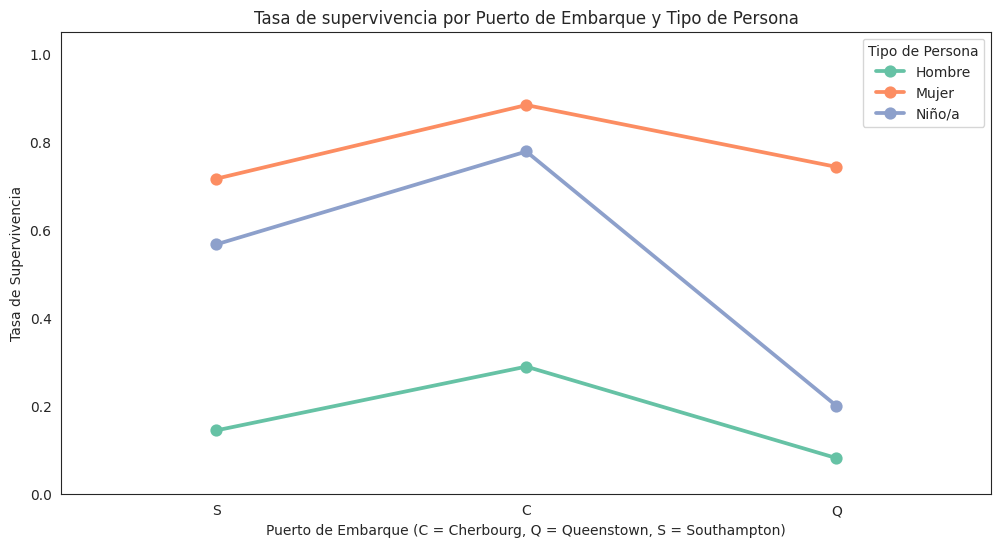

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [43]:
# Pregunta: ¿Existirá alguna relación entre el puerto de embarque el tipo de Persona y la tasa de Supervivencia?

# Código:
# Limpiamos cualquier espacio en blanco al inicio o al final del texto
titanic['Embarked'] = titanic['Embarked'].str.strip()

# Encontramos el puerto más frecuente automáticamente
puerto_comun = titanic['Embarked'].mode()[0]

# Rellenamos los valores vacíos (NaN) con ese puerto
titanic['Embarked'] = titanic['Embarked'].fillna(puerto_comun)
plt.figure(figsize=(12, 6))

sns.pointplot(x='Embarked', y='Survived', hue='Persona', data=titanic, palette='Set2', errorbar=None)

plt.title('Tasa de supervivencia por Puerto de Embarque y Tipo de Persona')
plt.xlabel('Puerto de Embarque (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Tasa de Supervivencia')

# La variable 'Fare' tiene unos pocos valores atípicos altísimos (ej. > 500)
# que "aplastan" el gráfico. Limitar el eje Y ayuda a ver mejor las distribuciones principales.
plt.ylim(0, 1.05) 

plt.legend(title='Tipo de Persona')
plt.show()
print(titanic['Embarked'].value_counts(dropna=False))

**RESPUESTA:**
- Al parecer hay una relación entre estas 3 variables, las mujeres siguen teniendo claramente la mayor tasa de supervivencia y los hombres la más baja. Pero además se ve como el puerto Cherbourg para los 3 tipos de persona son los que poseen la mayor fracción de supervivencia si lo comparamos con los otros 2 puertos.

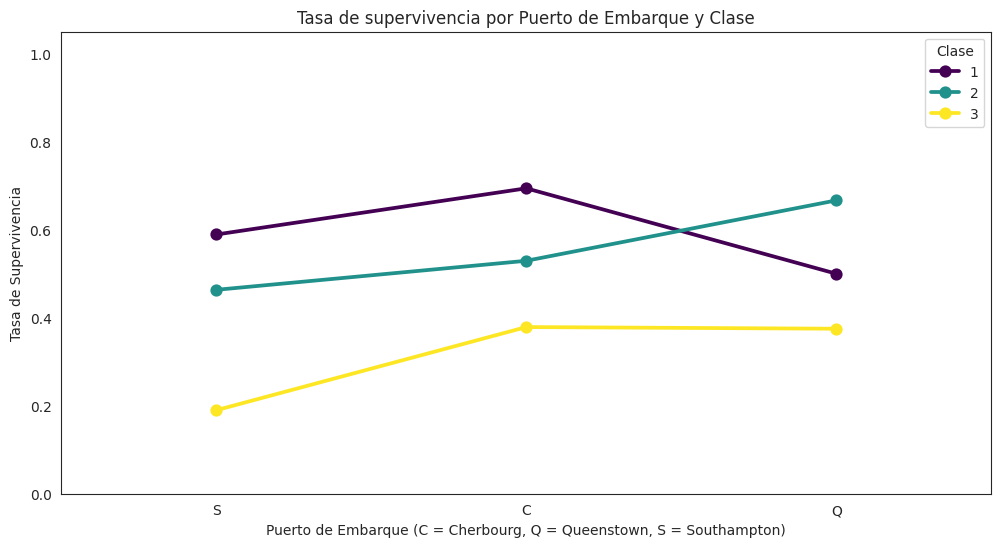

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [52]:
titanic['Embarked'] = titanic['Embarked'].str.strip()

# Encontramos el puerto más frecuente automáticamente
puerto_comun = titanic['Embarked'].mode()[0]

# Rellenamos los valores vacíos (NaN) con ese puerto
titanic['Embarked'] = titanic['Embarked'].fillna(puerto_comun)
plt.figure(figsize=(12, 6))

sns.pointplot(x='Embarked', y='Survived', hue='Pclass', data=titanic, palette='viridis', errorbar=None)

plt.title('Tasa de supervivencia por Puerto de Embarque y Clase')
plt.xlabel('Puerto de Embarque (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Tasa de Supervivencia')

# La variable 'Fare' tiene unos pocos valores atípicos altísimos (ej. > 500)
# que "aplastan" el gráfico. Limitar el eje Y ayuda a ver mejor las distribuciones principales.
plt.ylim(0, 1.05) 

plt.legend(title='Clase')
plt.show()
print(titanic['Embarked'].value_counts(dropna=False))

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

**CONCLUSIÓN:**
- Observación: Los pasajeros a bordo del titanic pertenecientes a la Clase 1 son los que mayor tasa de supervivencia presentan, sin importar la edad o el tipo de persona.
- Interpretación: El estatus socioeconómico (tipo de clase del pasajero) funcionó como una ventaja en la probabilidad de sobrevivir al hundimiento. Pertenecer a la Primera Clase otorgó un nivel de protección que, en la práctica, logró sobreponerse a otras variables como la edad o el género.
- Hipótesis: La tripulación podría haber alertado primero a los pasajeros de las clases altas, o bien, las normas sociales de la época provocaron que se les diera un trato preferencial al momento de asignar los asientos en los botes.

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.


### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.


**RESPUESTAS:**
1. Los pasajeros del titanic estaban compuestos de hombres, mujeres y niños. Los separaron en 3 clases, al parecer la clase 1 sería la de mayor privilegio. Las edades de los pasajeros abarca un gran rango, pero la mayor cantidad de pasajeros está entre los 20 y 30 años. También, algunos pasajeros viajaron con familiares, la tendencia es que en general viajaron solos, pero hay personas que viajaron con grandes grupos de familia (6 o más).
2. El sexo afecta bastante en la supervivencia, las mujeres sin importa la clase poseían la mayor tasa de supervivencia. También la clase 1 favorecia a la supervivencia, junto con la edad, los niños y también el puerto de embarque Cherbourg poseían mayores tasas de supervivencia. Por otro lado, el tamaño de la Familia no pareciera tener una distribución clara en la supervivencia, sino que más bien parece una coincidencia.
3. Que la clase 1 era la que más sobrevivió, esto cambio cuando se observó tanto el tipo de persona con la clase y supervivencia todo junto, los niños pertenecientes a la clase 2 son los niños que mayor tasa de sobrevivir tuvieron, lo cual rompe la tendencia que tenía la clase 1 para hombres y mujeres. 
4. Se podría decir que este es el caso de la tarifa y la clase, la clase 1 contiene a los pasajeros que mayor tarifa pagaron para poder abordar, a su vez la clase 3 concentra la mayor cantidad de pasajeros con tarifa baja. 
5. Observación: Me sorprendió que el puerto de embarque Cherbourg es el puerto que mayor porcentaje de supervivencia tuvo. 
- Interpretación: La mayor tasa de supervivencia asociada al puerto de Cherbourg no indica una ventaja por el lugar geográfico, sino que actúa como un reflejo del perfil demográfico y socioeconómico de los pasajeros que abordaron allí. Este puerto concentró a un grupo de personas que, en promedio, poseía características asociadas a una clase privilegiada y por tanto mayor probabilidad de rescate.
- Hipótesis: Este patrón es muy probablemente un "efecto secundario" de la clase socioeconómica. Como observamos anteriormente en el gráfico de las clases y el lugar de embarque, Cherbourg fue el punto de embarque donde subió una proporción significativamente mayor de pasajeros adinerados (Primera Clase). Dado que los pasajeros de Primera Clase tuvieron mejor acceso a los botes salvavidas y prioridad en la evacuación, la alta supervivencia de Cherbourg es simplemente el resultado matemático de tener más pasajeros de clase alta en su grupo.

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*


**CONCLUSIÓN FINAL:**
El pasajero típico que sobrevivió se perfila claramente como una mujer perteneciente a la Primera Clase. Las visualizaciones demuestran que el estatus socioeconómico y las normas sociales de evacuación fueron determinantes, lo cual se refleja en que este perfil pagó una tarifa significativamente superior al promedio y embarcó mayoritariamente en el puerto de Cherbourg. Además, el análisis revela un patrón contraintuitivo respecto a la compañía a bordo: las probabilidades óptimas de rescate no se dieron en pasajeros que viajaban completamente solos ni en aquellos con familias muy numerosas, sino en quienes conformaban un grupo familiar mediano de exactamente 4 personas.